# 09. Options EDA

Deep dive on `data/strategy_labels.parquet` (64,339 rows, 35 HQ tickers, 2020-01-06 → 2026-03-23).

Five questions, each answered with a table + chart:

1. **Overview** — shape, date range, per-type headline numbers
2. **Market calibration** — does BS-implied P(success) from delta match the realized assignment rate? (If yes, option pricing is fair; if realized > implied, there's structural edge to selling.)
3. **IV regime segmentation** — does the strategy work better in high-IV or low-IV weeks?
4. **Per-ticker edge** — which HQ tickers are consistently profitable at CSP 3% yield, with 95% CI error bars
5. **Year-over-year trend** — has performance degraded or improved over time?

None of these require price prediction — they're all describing what the data shows. The price model in 05-08 then targets whatever residual edge exists after these baselines.


In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
OUT_DIR = Path("output/05_options_eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IV_BINS = [0.0, 0.30, 0.50, 0.80, 1.20, 10.0]
IV_LABELS = ["< 30", "30-50", "50-80", "80-120", "> 120"]
CALIB_BINS = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]

## Load + derive columns


In [2]:
labels = pd.read_parquet(LABELS_PATH)
labels["pnl_pct_capital_mark"] = labels["net_pnl_mark"] / labels["capital_per_contract"]
labels["year"] = labels["monday_date"].dt.year
labels["iv_bucket"] = pd.cut(
    labels["iv"], bins=IV_BINS, labels=IV_LABELS, include_lowest=True
)
print(f"Loaded {len(labels):,} rows, {labels['ticker'].nunique()} tickers")
print(
    f"Date range: {labels['monday_date'].min().date()} -> {labels['monday_date'].max().date()}"
)

Loaded 64,339 rows, 35 tickers
Date range: 2020-01-06 -> 2026-03-23


## 1. Overview

Per-type headline: how often did each strategy end up OTM, and what's the realized mean PnL under bid-fill (conservative) and mark-fill (idealized).


In [3]:
print(f"Rows: {len(labels):,}")
print(f"Tickers: {labels['ticker'].nunique()}")
print(
    f"Date range: {labels['monday_date'].min().date()} -> {labels['monday_date'].max().date()}"
)
print(f"Yield targets: {sorted(labels['yield_target'].unique())}")
print(f"Types: {sorted(labels['type'].unique())}")
print()
print("Per type:")
for t, g in labels.groupby("type"):
    print(
        f"  {t}: {len(g):,} rows | "
        f"assigned={100 * g['assigned'].mean():.1f}% | "
        f"mean_pnl_bid={100 * g['pnl_pct_capital'].mean():+.3f}% | "
        f"mean_pnl_mark={100 * g['pnl_pct_capital_mark'].mean():+.3f}%"
    )

Rows: 64,339
Tickers: 35
Date range: 2020-01-06 -> 2026-03-23
Yield targets: [np.float64(0.005), np.float64(0.01), np.float64(0.015), np.float64(0.02), np.float64(0.025), np.float64(0.03), np.float64(0.035), np.float64(0.04), np.float64(0.045), np.float64(0.05)]
Types: ['CC', 'CSP']

Per type:
  CC: 32,941 rows | assigned=32.0% | mean_pnl_bid=-0.466% | mean_pnl_mark=-0.340%
  CSP: 31,398 rows | assigned=32.5% | mean_pnl_bid=-0.056% | mean_pnl_mark=+0.073%


## 2. Market calibration

For each bucket of `p_mkt_success` (= `1 - |delta|`, the market's implied probability this option expires OTM), compute the realized success rate. Under efficient pricing they should line up on y=x. Systematic deviation is either a data issue or a real structural edge.


In [4]:
calib_rows = []
for t in ["CC", "CSP"]:
    sub = labels[labels["type"] == t].copy()
    sub["p_bucket"] = pd.cut(sub["p_mkt_success"], bins=CALIB_BINS, include_lowest=True)
    for bucket, g in sub.groupby("p_bucket", observed=True):
        if len(g) < 50:
            continue
        calib_rows.append(
            {
                "type": t,
                "p_mkt_bucket": str(bucket),
                "p_mkt_mid": (bucket.left + bucket.right) / 2,
                "n": len(g),
                "realized_success": float((~g["assigned"]).mean()),
                "mean_pnl_bid_pct": round(100 * g["pnl_pct_capital"].mean(), 3),
            }
        )
calibration = pd.DataFrame(calib_rows)
calibration

,type,p_mkt_bucket,p_mkt_mid,n,realized_success,mean_pnl_bid_pct
0,CC,"(0.499, 0.6]",0.5495,10883,0.571350,-0.411
1,CC,"(0.6, 0.7]",0.6500,7376,0.676518,-0.606
2,CC,"(0.7, 0.8]",0.7500,6593,0.765509,-0.528
3,CC,"(0.8, 0.85]",0.8250,2792,0.838825,-0.458
4,CC,"(0.85, 0.9]",0.8750,1866,0.886388,-0.306
5,CC,"(0.9, 0.95]",0.9250,901,0.932297,-0.136
6,CSP,"(0.499, 0.6]",0.5495,9919,0.531707,-0.183
7,CSP,"(0.6, 0.7]",0.6500,7565,0.625116,-0.074
8,CSP,"(0.7, 0.8]",0.7500,6891,0.738354,0.042
9,CSP,"(0.8, 0.85]",0.8250,3025,0.819174,-0.019


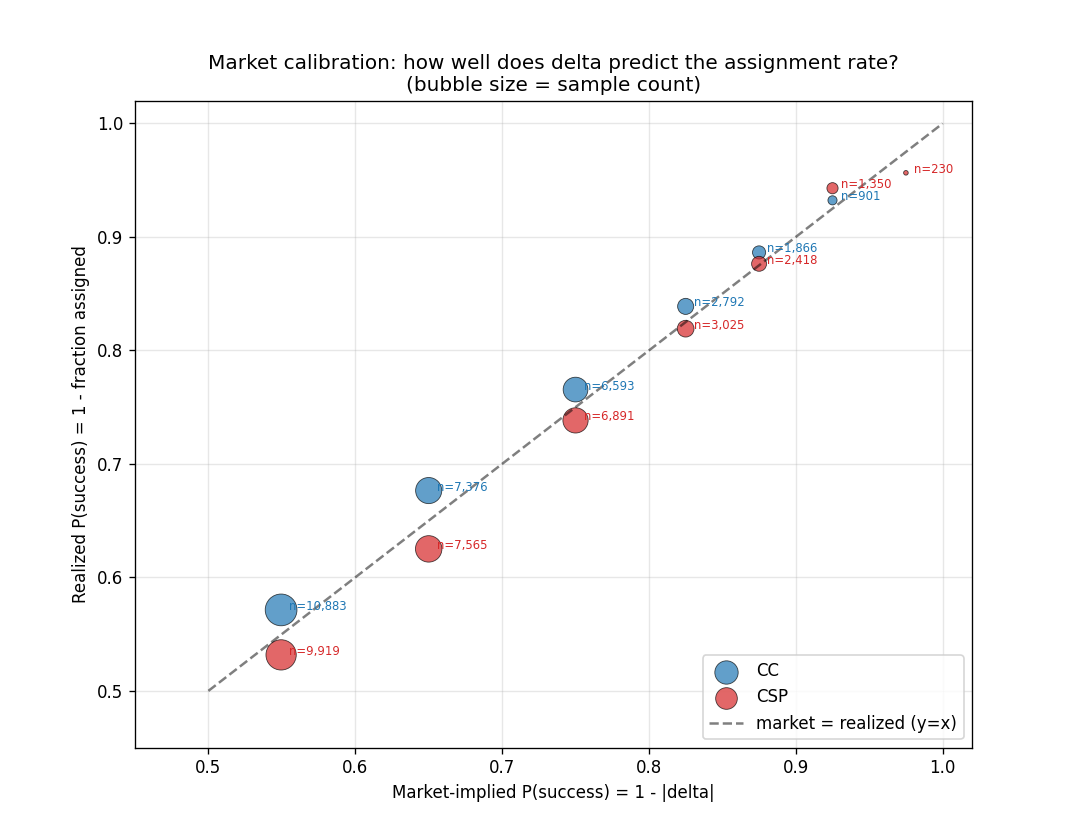

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
for t, color in [("CC", "tab:blue"), ("CSP", "tab:red")]:
    sub = calibration[calibration["type"] == t]
    ax.scatter(
        sub["p_mkt_mid"],
        sub["realized_success"],
        s=sub["n"] / 30,
        color=color,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.5,
        label=t,
    )
    for _, r in sub.iterrows():
        ax.annotate(
            f"n={r['n']:,}",
            (r["p_mkt_mid"], r["realized_success"]),
            fontsize=7,
            xytext=(5, 0),
            textcoords="offset points",
            color=color,
        )
ax.plot([0.5, 1.0], [0.5, 1.0], "k--", alpha=0.5, label="market = realized (y=x)")
ax.set_xlabel("Market-implied P(success) = 1 - |delta|")
ax.set_ylabel("Realized P(success) = 1 - fraction assigned")
ax.set_title(
    "Market calibration: how well does delta predict the assignment rate?\n(bubble size = sample count)"
)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
ax.set_xlim(0.45, 1.02)
ax.set_ylim(0.45, 1.02)
fig.savefig(OUT_DIR / "calibration.png", dpi=120)
plt.show()
plt.close(fig)

## 3. IV regime segmentation

Bucket each row by its entry-time implied volatility. Options-selling strategies typically shine in high-IV regimes (fat premium and mean-reverting vol) and struggle in low-IV regimes (premium too thin to compensate for tail risk).


In [6]:
iv_agg_rows = []
for (type_, iv_bucket), g in labels.groupby(["type", "iv_bucket"], observed=True):
    if len(g) < 100:
        continue
    pnl_bid = g["pnl_pct_capital"]
    sharpe = float(pnl_bid.mean() / pnl_bid.std()) if pnl_bid.std() > 0 else 0.0
    iv_agg_rows.append(
        {
            "type": type_,
            "iv_bucket": str(iv_bucket),
            "n": len(g),
            "pct_OTM_at_exp": round(100 * (~g["assigned"]).mean(), 2),
            "median_yield_actual_pct": round(100 * g["yield_actual"].median(), 3),
            "mean_pnl_bid_pct": round(100 * pnl_bid.mean(), 3),
            "mean_pnl_mark_pct": round(100 * g["pnl_pct_capital_mark"].mean(), 3),
            "sharpe_annual": round(sharpe * math.sqrt(52), 3),
        }
    )
iv_agg = pd.DataFrame(iv_agg_rows)
iv_agg

,type,iv_bucket,n,pct_OTM_at_exp,median_yield_actual_pct,mean_pnl_bid_pct,mean_pnl_mark_pct,sharpe_annual
0,CC,< 30,1676,59.07,0.607,-0.146,-0.116,-0.676
1,CC,30-50,6904,62.57,1.049,-0.204,-0.160,-0.629
2,CC,50-80,8734,65.01,1.664,-0.421,-0.353,-0.737
3,CC,80-120,8631,69.53,2.559,-0.418,-0.266,-0.474
4,CC,> 120,6996,77.43,2.697,-0.917,-0.648,-0.696
5,CSP,< 30,1468,66.49,0.612,-0.016,0.018,-0.083
6,CSP,30-50,6494,66.65,1.042,-0.064,-0.016,-0.153
7,CSP,50-80,8840,65.66,1.581,-0.183,-0.109,-0.326
8,CSP,80-120,8430,64.32,2.500,-0.173,-0.015,-0.241
9,CSP,> 120,6166,75.43,2.826,0.287,0.563,0.344


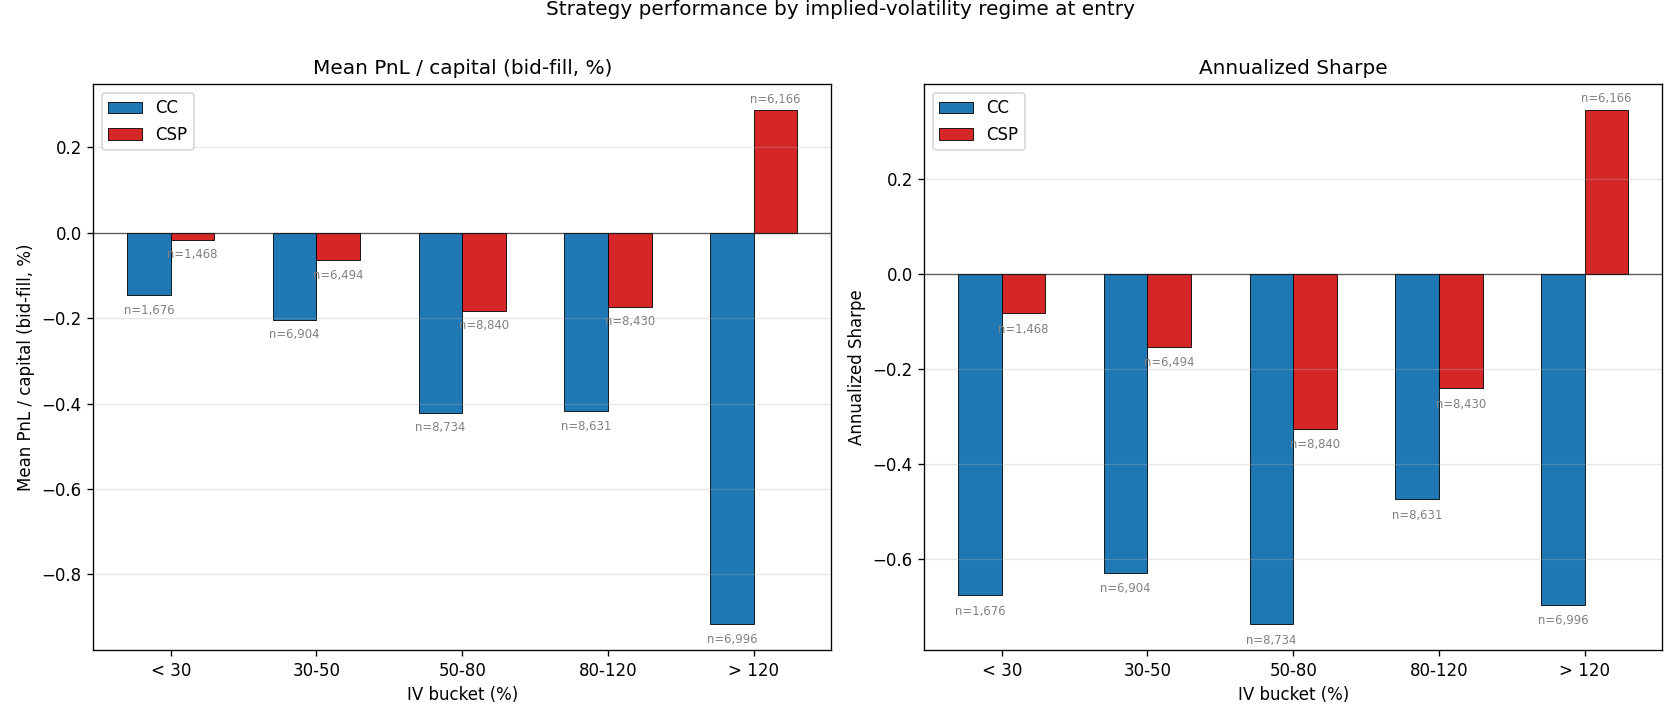

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, metric, title in [
    (axes[0], "mean_pnl_bid_pct", "Mean PnL / capital (bid-fill, %)"),
    (axes[1], "sharpe_annual", "Annualized Sharpe"),
]:
    x_positions = range(len(IV_LABELS))
    for t, color, offset in [("CC", "tab:blue", -0.15), ("CSP", "tab:red", 0.15)]:
        vals, counts = [], []
        for lbl in IV_LABELS:
            row = iv_agg[(iv_agg["type"] == t) & (iv_agg["iv_bucket"] == lbl)]
            if row.empty:
                vals.append(0)
                counts.append(0)
            else:
                vals.append(row[metric].iloc[0])
                counts.append(row["n"].iloc[0])
        bars = ax.bar(
            [x + offset for x in x_positions],
            vals,
            width=0.3,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            label=t,
        )
        for bar, n in zip(bars, counts):
            if n > 0:
                y_text = (
                    bar.get_height() + 0.01
                    if bar.get_height() >= 0
                    else bar.get_height() - 0.02
                )
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    y_text,
                    f"n={n:,}",
                    ha="center",
                    va="bottom" if bar.get_height() >= 0 else "top",
                    fontsize=7,
                    color="gray",
                )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(IV_LABELS)
    ax.set_xlabel("IV bucket (%)")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")
    ax.legend()
fig.suptitle("Strategy performance by implied-volatility regime at entry", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "iv_regime.png", dpi=120)
plt.show()
plt.close(fig)

## 4. Per-ticker edge with confidence intervals

For each HQ ticker × type at the 3% yield target, compute mean weekly PnL (bid-fill) with 95% CI from 1.96 × SEM. Tickers whose CI sits cleanly on one side of zero are candidates for whitelisting (or blacklisting).


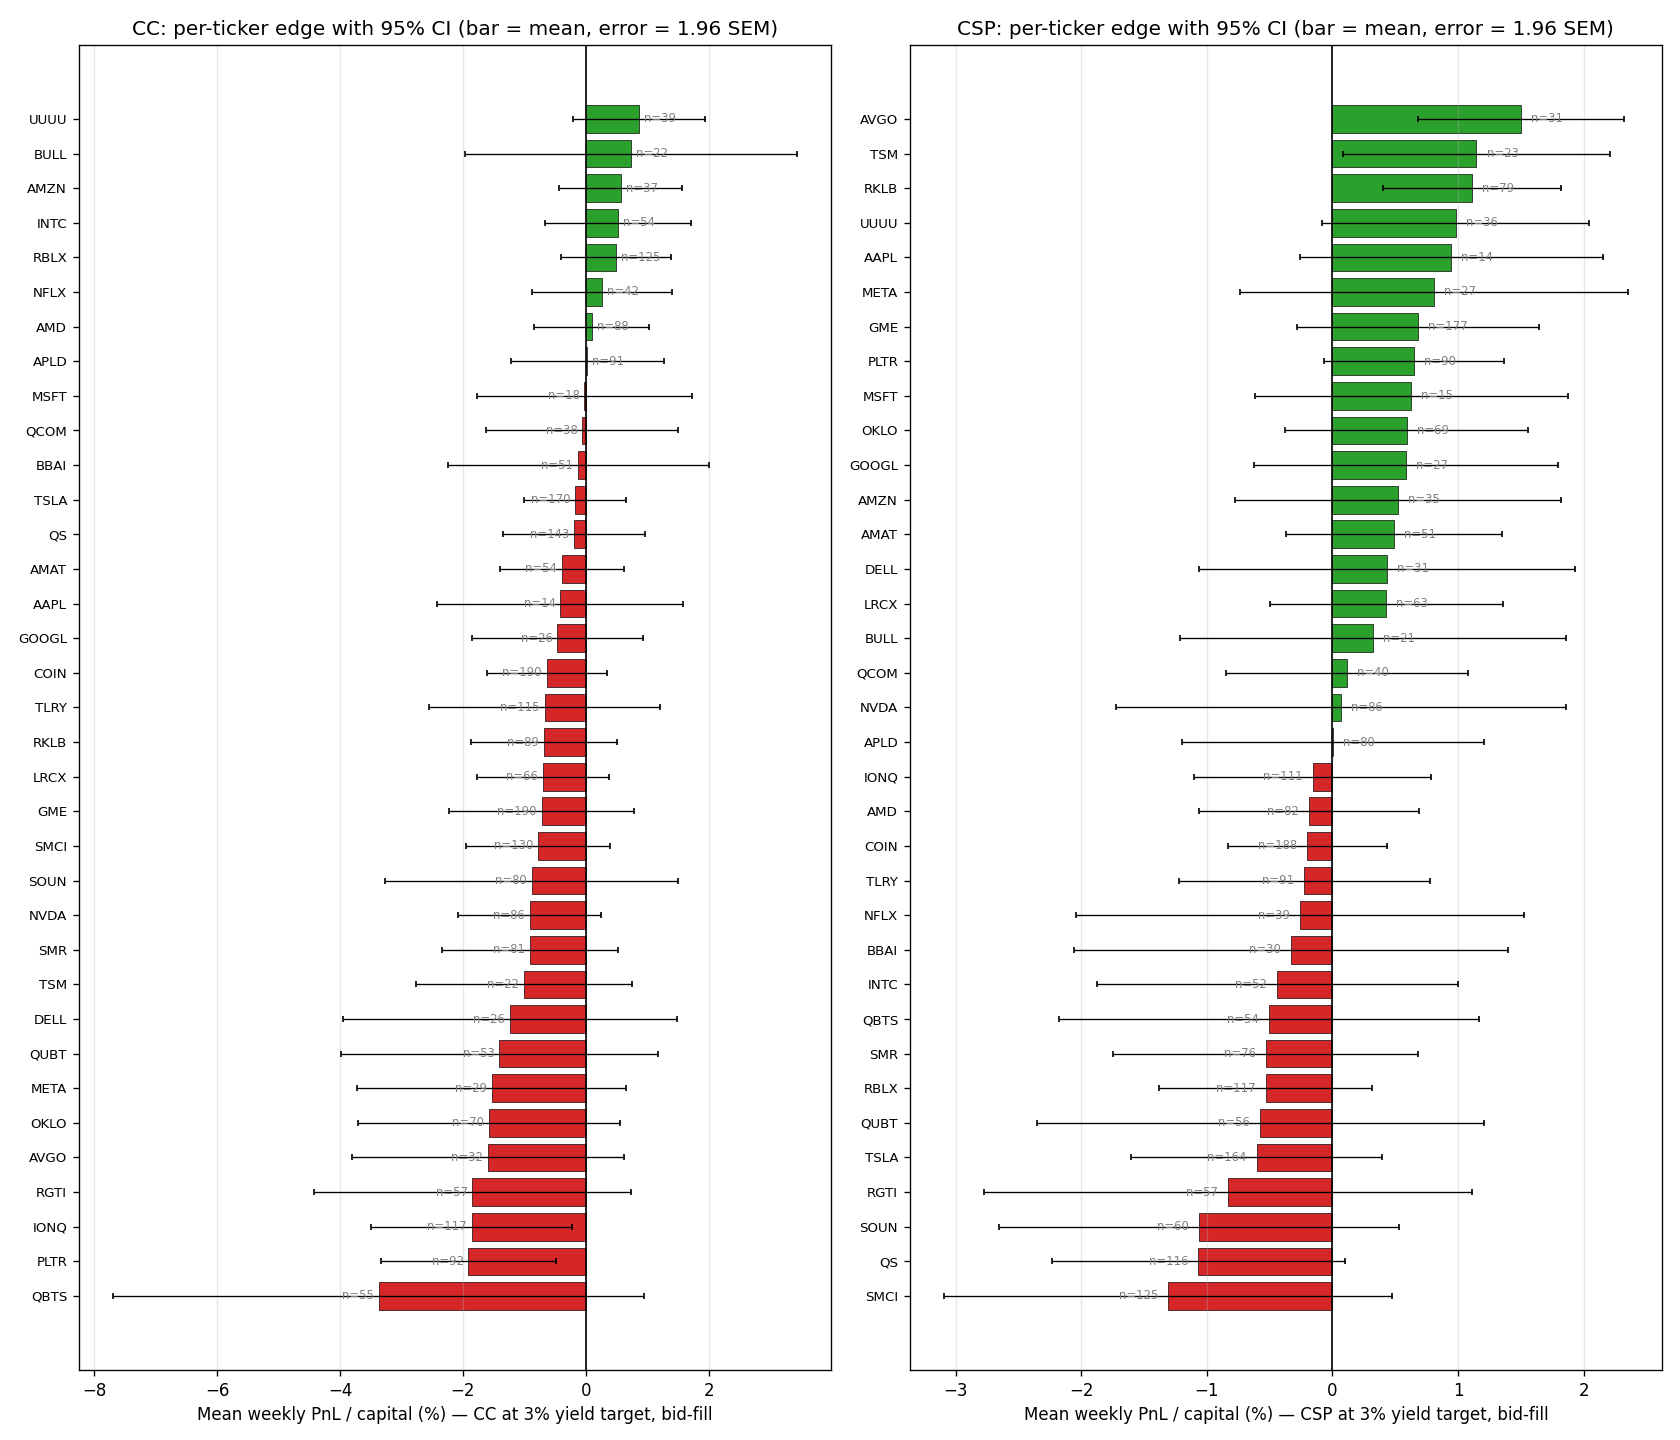

In [8]:
ticker_rows = []
for (ticker, type_), g in labels[labels["yield_target"] == 0.03].groupby(
    ["ticker", "type"]
):
    pnl = g["pnl_pct_capital"]
    if len(pnl) < 5:
        continue
    mean = float(pnl.mean())
    sem = float(pnl.std() / math.sqrt(len(pnl))) if len(pnl) > 1 else 0.0
    ticker_rows.append(
        {
            "ticker": ticker,
            "type": type_,
            "n": len(pnl),
            "mean_pnl_bid_pct": 100 * mean,
            "sem_pct": 100 * sem,
            "ci95_low_pct": 100 * (mean - 1.96 * sem),
            "ci95_high_pct": 100 * (mean + 1.96 * sem),
        }
    )
per_ticker = pd.DataFrame(ticker_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 12), sharex=False)
for ax, t in zip(axes, ["CC", "CSP"]):
    sub = per_ticker[per_ticker["type"] == t].sort_values("mean_pnl_bid_pct")
    y = range(len(sub))
    errs = sub["sem_pct"] * 1.96
    colors = ["tab:green" if v >= 0 else "tab:red" for v in sub["mean_pnl_bid_pct"]]
    ax.barh(
        list(y),
        sub["mean_pnl_bid_pct"],
        xerr=errs,
        color=colors,
        edgecolor="black",
        linewidth=0.4,
        error_kw={"ecolor": "black", "elinewidth": 0.8, "capsize": 2},
    )
    ax.set_yticks(list(y))
    ax.set_yticklabels(sub["ticker"], fontsize=8)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel(f"Mean weekly PnL / capital (%) - {t} at 3% yield target, bid-fill")
    ax.grid(alpha=0.3, axis="x")
    ax.set_title(f"{t}: per-ticker edge with 95% CI (bar = mean, error = 1.96 SEM)")
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(
            row["mean_pnl_bid_pct"] + (0.08 if row["mean_pnl_bid_pct"] >= 0 else -0.08),
            i,
            f"n={row['n']}",
            va="center",
            ha="left" if row["mean_pnl_bid_pct"] >= 0 else "right",
            fontsize=7,
            color="gray",
        )
fig.tight_layout()
fig.savefig(OUT_DIR / "per_ticker_edge.png", dpi=120)
plt.show()
plt.close(fig)

## 5. Year-over-year trend

Tells you whether the strategy has degraded, improved, or stayed the same. If mean PnL declined, premium has gotten thinner (crowded trade). If IV collapsed, premium availability is part of the reason.


In [9]:
year_rows = []
for (year, type_), g in labels.groupby(["year", "type"]):
    if len(g) < 50:
        continue
    pnl = g["pnl_pct_capital"]
    sharpe = float(pnl.mean() / pnl.std()) if pnl.std() > 0 else 0.0
    year_rows.append(
        {
            "year": int(year),
            "type": type_,
            "n": len(g),
            "pct_OTM_at_exp": round(100 * (~g["assigned"]).mean(), 2),
            "mean_pnl_bid_pct": round(100 * pnl.mean(), 3),
            "mean_pnl_mark_pct": round(100 * g["pnl_pct_capital_mark"].mean(), 3),
            "median_iv": round(g["iv"].median(), 3),
            "sharpe_annual": round(sharpe * math.sqrt(52), 3),
        }
    )
year_agg = pd.DataFrame(year_rows)
year_agg

,year,type,n,pct_OTM_at_exp,mean_pnl_bid_pct,mean_pnl_mark_pct,median_iv,sharpe_annual
0,2020,CC,3318,65.58,-0.636,-0.459,0.634,-0.725
1,2020,CSP,3261,72.62,0.616,0.816,0.649,1.763
2,2021,CC,3786,70.34,-0.228,-0.142,0.639,-0.261
3,2021,CSP,3706,67.86,-0.077,0.022,0.639,-0.128
4,2022,CC,4935,73.13,0.097,0.189,0.727,0.139
5,2022,CSP,4901,60.23,-0.529,-0.442,0.756,-0.714
6,2023,CC,4381,60.17,-0.880,-0.761,0.639,-1.284
7,2023,CSP,4064,70.18,0.175,0.279,0.620,0.370
8,2024,CC,5693,64.85,-0.802,-0.649,0.766,-0.880
9,2024,CSP,5241,70.79,-0.054,0.091,0.727,-0.067


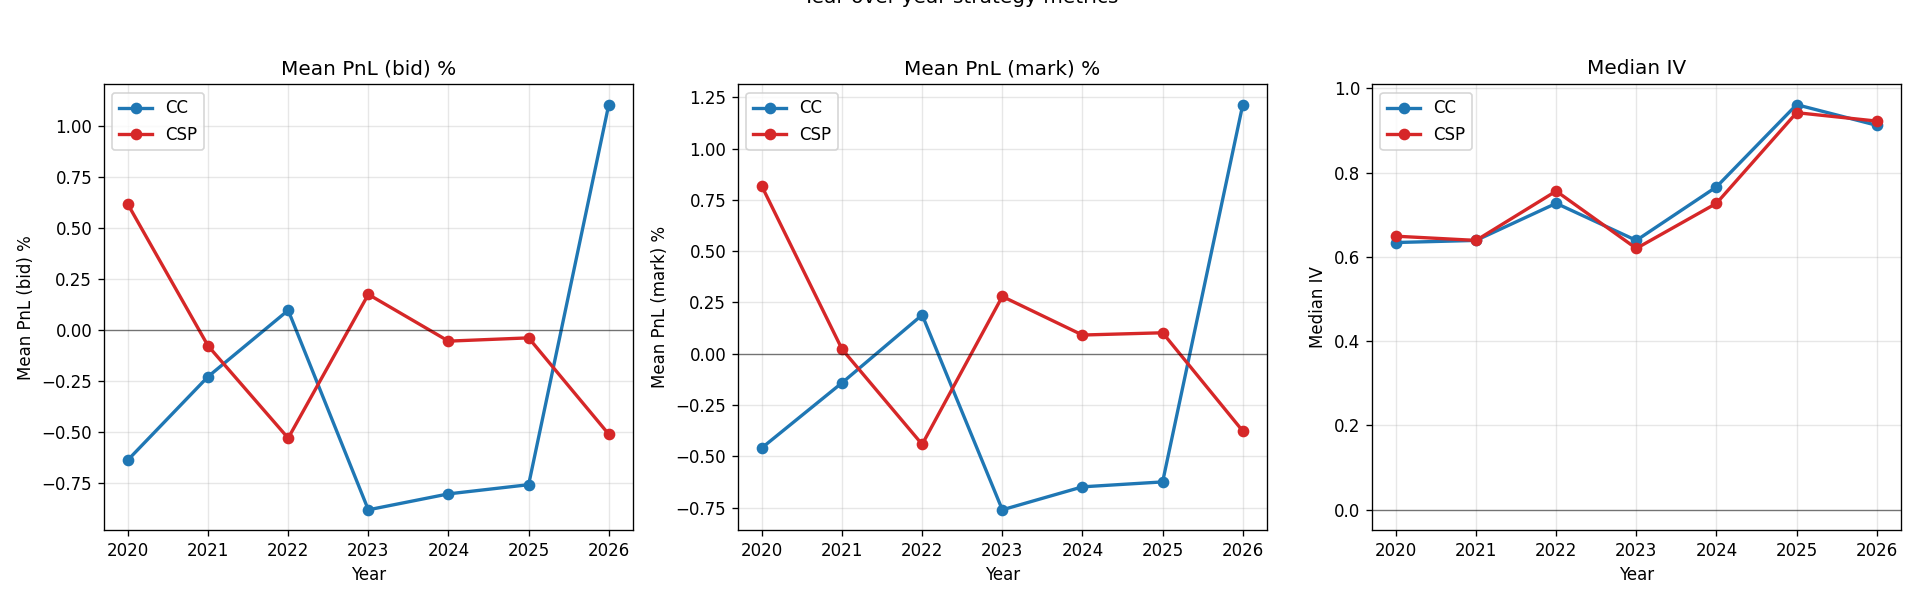

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in [
    (axes[0], "mean_pnl_bid_pct", "Mean PnL (bid) %"),
    (axes[1], "mean_pnl_mark_pct", "Mean PnL (mark) %"),
    (axes[2], "median_iv", "Median IV"),
]:
    for t, color in [("CC", "tab:blue"), ("CSP", "tab:red")]:
        sub = year_agg[year_agg["type"] == t]
        ax.plot(sub["year"], sub[metric], marker="o", color=color, label=t, linewidth=2)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Year")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle("Year-over-year strategy metrics", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "year_trend.png", dpi=120)
plt.show()
plt.close(fig)